In [3]:
!pip install astropy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import urllib.request

# Correct 4FGL-DR4 catalog URL
print("Downloading 4FGL-DR4 catalog...")
url = "https://fermi.gsfc.nasa.gov/ssc/data/access/lat/14yr_catalog/gll_psc_v35.fit"
urllib.request.urlretrieve(url, "4fgl_dr4.fit")
print("Done!")

# Load it
cat = Table.read("4fgl_dr4.fit", hdu=1)
print(f"\nTotal sources in catalog: {len(cat)}")
print(f"\nFirst 10 column names: {cat.colnames[:10]}")

Done!

Total sources in catalog: 7195

First 10 column names: ['Source_Name', 'DataRelease', 'RAJ2000', 'DEJ2000', 'GLON', 'GLAT', 'Conf_68_SemiMajor', 'Conf_68_SemiMinor', 'Conf_68_PosAng', 'Conf_95_SemiMajor']


=== SOURCE CLASSES IN 4FGL-DR4 ===
  --  '--'  2423
  bcu    'bcu  '  1622
  bll    'bll  '  1468
  fsrq   'fsrq '  776
  MSP    'MSP  '  139
  unk    'unk  '  137
  PSR    'PSR  '  137
  spp    'spp  '  126
  rdg    'rdg  '  47
  FSRQ   'FSRQ '  44
  glc    'glc  '  41
  msp    'msp  '  40
  SNR    'SNR  '  26
  BLL    'BLL  '  22
  snr    'snr  '  18

Total sources:       7195
Unassociated:        0
Associated:          7195


/tmp/ipykernel_39209/829609393.py:9: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"  {n:>5}  '{str(n)}'  {str(c)}")


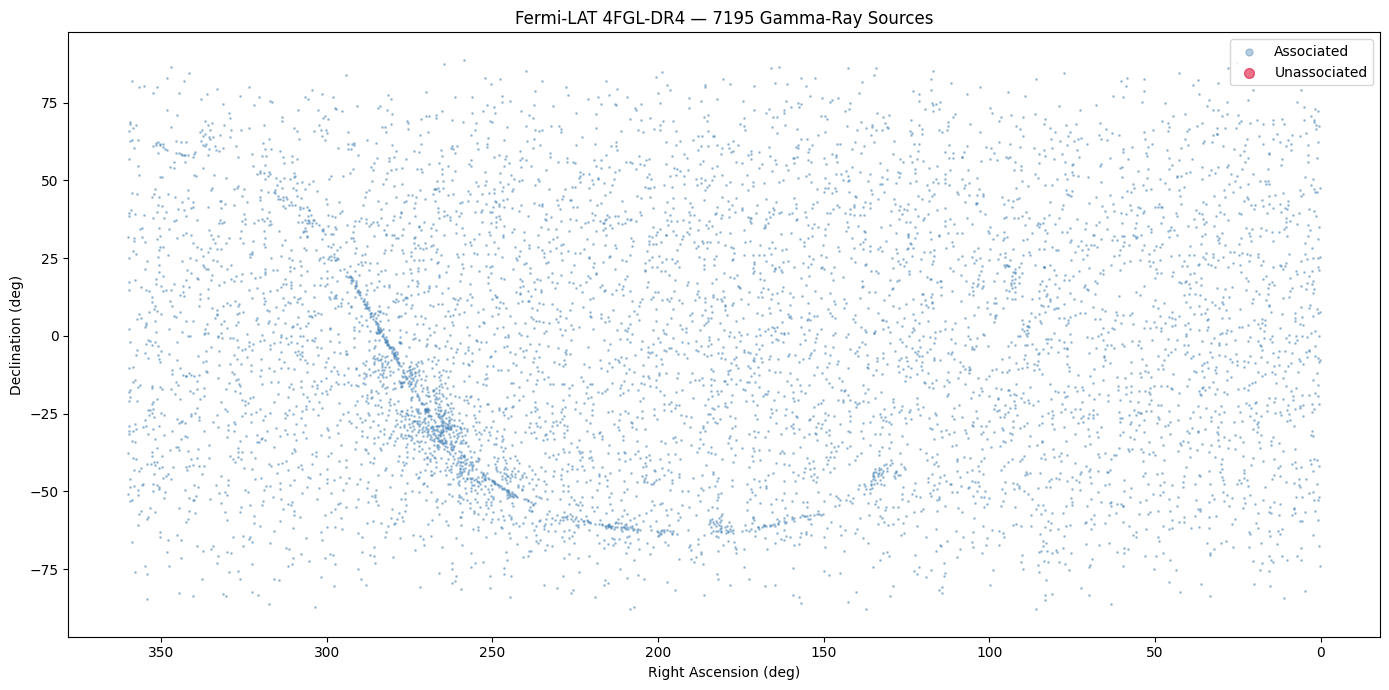

Sky map saved!


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. What source classes exist? ──────────────────────────
classes = cat['CLASS1']
unique, counts = np.unique(classes, return_counts=True)
print("=== SOURCE CLASSES IN 4FGL-DR4 ===")
for c, n in sorted(zip(counts, unique), reverse=True)[:15]:
    print(f"  {n:>5}  '{str(n)}'  {str(c)}")

# ── 2. How many are UNASSOCIATED? ──────────────────────────
unassoc_mask = (cat['CLASS1'] == b'') | (cat['CLASS1'] == b' ')
n_unassoc = np.sum(unassoc_mask)
print(f"\nTotal sources:       {len(cat)}")
print(f"Unassociated:        {n_unassoc}")
print(f"Associated:          {len(cat) - n_unassoc}")

# ── 3. Sky map of ALL sources ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ra  = cat['RAJ2000']
dec = cat['DEJ2000']

# plot associated vs unassociated in different colours
ax.scatter(ra[~unassoc_mask], dec[~unassoc_mask],
           s=1, alpha=0.4, color='steelblue', label='Associated')
ax.scatter(ra[unassoc_mask],  dec[unassoc_mask],
           s=2, alpha=0.6, color='crimson',   label='Unassociated')

ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Fermi-LAT 4FGL-DR4 — 7195 Gamma-Ray Sources')
ax.legend(markerscale=5)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('4fgl_skymap.png', dpi=150)
plt.show()
print("Sky map saved!")

Total sources:       7195
Unassociated ('--'): 2560
Known classes:       4635


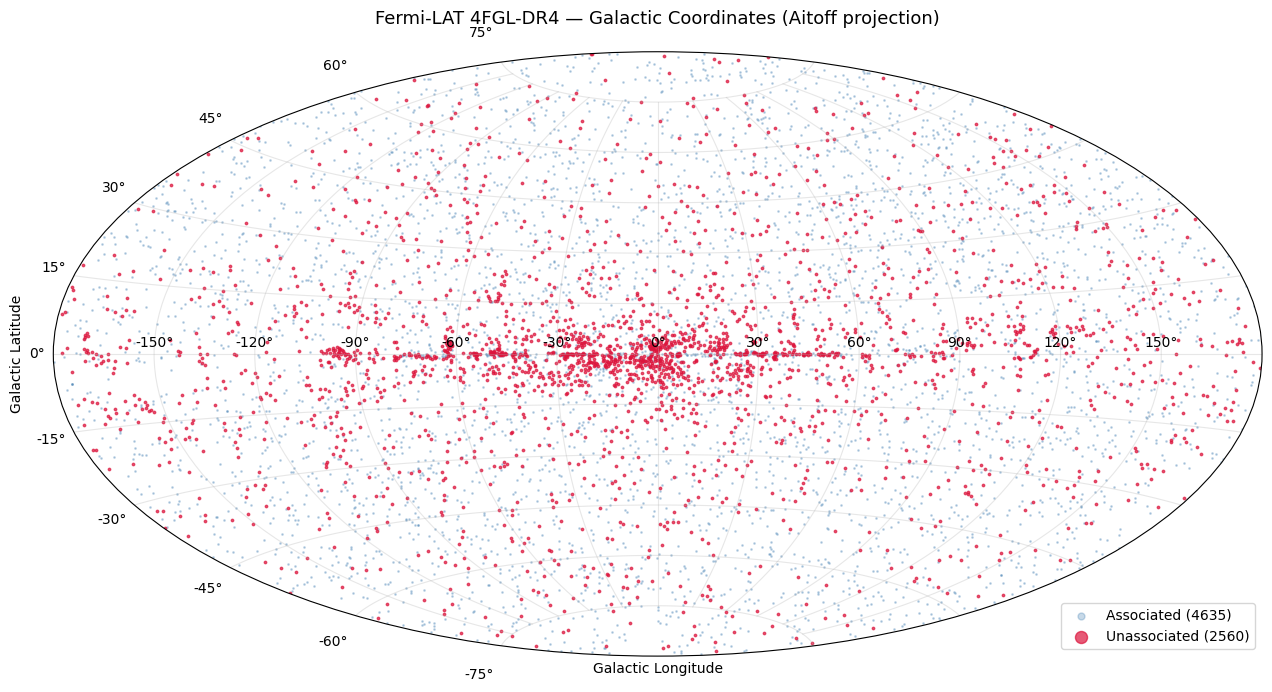


Unassociated sources: 2560
This is your Tier 3 ML search space.


In [5]:
# Fix unassociated mask — in this catalog version they're encoded as '--'
unassoc_mask = np.array([str(c).strip() in ['--', '', 'unk']
                          for c in cat['CLASS1']])

n_unassoc = np.sum(unassoc_mask)
print(f"Total sources:       {len(cat)}")
print(f"Unassociated ('--'): {n_unassoc}")
print(f"Known classes:       {len(cat) - n_unassoc}")

# ── Better sky map in Galactic coordinates ─────────────────
glon = np.array(cat['GLON'], dtype=float)
glat = np.array(cat['GLAT'], dtype=float)

# Convert to radians, center on l=0
glon_rad = np.radians(glon)
glon_rad[glon_rad > np.pi] -= 2*np.pi  # wrap to [-π, π]

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='aitoff')

ax.scatter(glon_rad[~unassoc_mask], np.radians(glat[~unassoc_mask]),
           s=1, alpha=0.3, color='steelblue', label=f'Associated ({(~unassoc_mask).sum()})')
ax.scatter(glon_rad[unassoc_mask],  np.radians(glat[unassoc_mask]),
           s=3, alpha=0.7, color='crimson',
           label=f'Unassociated ({unassoc_mask.sum()})')

ax.set_title('Fermi-LAT 4FGL-DR4 — Galactic Coordinates (Aitoff projection)',
             pad=20, fontsize=13)
ax.legend(markerscale=5, loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')
plt.tight_layout()
plt.savefig('4fgl_galactic_skymap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nUnassociated sources: {n_unassoc}")
print("This is your Tier 3 ML search space.")
